In [2]:

# Create a validation split to test locally
import pandas as pd
import numpy as np

train_df = pd.read_csv('train.csv')

# Time-based split (80-20)
train_df = train_df.sort_values('timestamp')
split_time = train_df['timestamp'].quantile(0.8)

train_data = train_df[train_df['timestamp'] < split_time]
valid_data = train_df[train_df['timestamp'] >= split_time]

# Save for later use
train_data.to_csv('train_split.csv', index=False)
valid_data.to_csv('valid_split.csv', index=False)

In [4]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.2-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-macosx_10_13_x86_64.whl.metadata (6.2 kB)
  Using cached pillow-11.2.1-cp313-cp313-macosx_10_13_x86_64.whl.metadata (8.9 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 8.2 MB/s eta 0:00:00a 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.2-cp313-cp313-macosx_10_13_x86_64.whl (271 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.7 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.8-cp313-cp313-macosx_10_13_x86_64.whl (66 kB)
Using cached pillow-11.2.1-cp313-cp313-macosx_10_13_x86_64.whl (3.2 MB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)

Users with only 1 interaction: 303478 (93.8%)
Users with 2-5 interactions: 19856
Power users (>50 interactions): 3


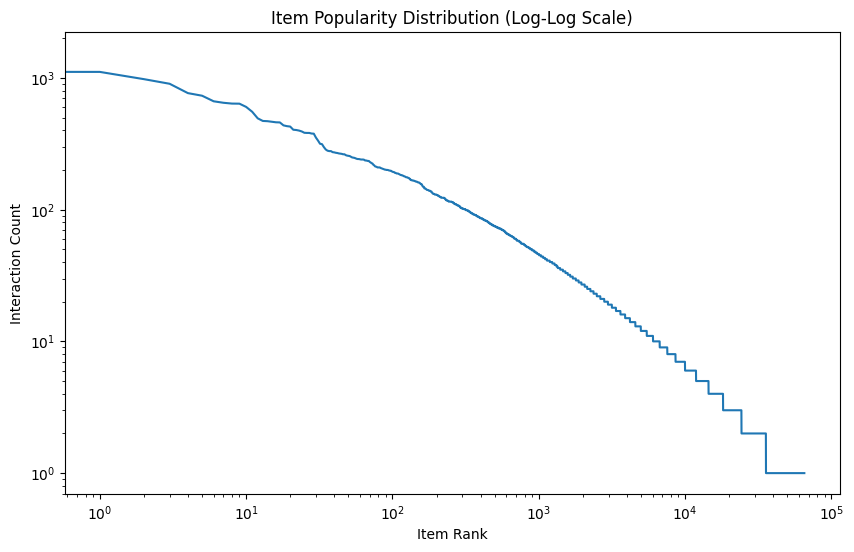


Top 10 Categories:
main_category
All Beauty        319883
Premium Beauty      2745
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. User behavior patterns
user_counts = train_df['user_id'].value_counts()
print(f"Users with only 1 interaction: {(user_counts == 1).sum()} ({(user_counts == 1).sum() / len(user_counts) * 100:.1f}%)")
print(f"Users with 2-5 interactions: {((user_counts >= 2) & (user_counts <= 5)).sum()}")
print(f"Power users (>50 interactions): {(user_counts > 50).sum()}")

# 2. Item popularity distribution
item_counts = train_df['item_id'].value_counts()
plt.figure(figsize=(10, 6))
plt.loglog(range(len(item_counts)), item_counts.values)
plt.title('Item Popularity Distribution (Log-Log Scale)')
plt.xlabel('Item Rank')
plt.ylabel('Interaction Count')
plt.show()

# 3. Temporal patterns
train_df['timestamp_dt'] = pd.to_datetime(train_df['timestamp'], unit='ms')
train_df['hour'] = train_df['timestamp_dt'].dt.hour
train_df['day_of_week'] = train_df['timestamp_dt'].dt.dayofweek

hourly_pattern = train_df.groupby('hour').size()
daily_pattern = train_df.groupby('day_of_week').size()

# 4. Category analysis
item_meta = pd.read_csv('item_meta.csv')
train_with_meta = train_df.merge(item_meta[['item_id', 'main_category']], on='item_id', how='left')
category_dist = train_with_meta['main_category'].value_counts()
print("\nTop 10 Categories:")
print(category_dist.head(10))

In [10]:
# Create rich user features
def create_user_features(train_df, item_meta_df):
    user_features = {}
    
    for user_id in train_df['user_id'].unique():
        user_data = train_df[train_df['user_id'] == user_id]
        user_items = user_data.merge(item_meta_df, on='item_id', how='left')
        
        features = {
            'user_id': user_id,
            'total_interactions': len(user_data),
            'unique_items': user_data['item_id'].nunique(),
            'avg_price': user_items['price'].mean(),
            'price_std': user_items['price'].std(),
            'favorite_category': user_items['main_category'].mode()[0] if len(user_items) > 0 else None,
            'category_diversity': user_items['main_category'].nunique(),
            'time_span_days': (user_data['timestamp'].max() - user_data['timestamp'].min()) / 86400000,
            'interactions_per_day': len(user_data) / max(1, (user_data['timestamp'].max() - user_data['timestamp'].min()) / 86400000),
            'weekend_ratio': (user_items['day_of_week'].isin([5, 6]).sum()) / len(user_items),
            'night_owl_score': (user_items['hour'].isin([22, 23, 0, 1, 2]).sum()) / len(user_items),
        }
        user_features[user_id] = features
    
    return pd.DataFrame.from_dict(user_features, orient='index')

user_features_df = create_user_features(train_df, item_meta)
user_features_df.to_csv('user_features.csv', index=False)

KeyError: 0